# Exploratory Data Analysis (EDA)

## Project
Hybrid Ensemble-Based Phishing Website Detection Using Machine Learning

## Dataset
PhiUSIIL Phishing URL Dataset

## Objective

This notebook performs exploratory data analysis to evaluate the quality of the dataset, understand feature characteristics, identify preprocessing requirements, and support the design of the phishing detection models.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")

Matplotlib is building the font cache; this may take a moment.


# 1. Load Dataset

The dataset is loaded from the raw data directory. This dataset contains URL-based features extracted from phishing and legitimate websites.

In [3]:
DATA_PATH = "../data/raw/PhiUSIIL_Phishing_URL_Dataset.csv"

df = pd.read_csv(DATA_PATH)

In [4]:
print("shape:",df.shape)

shape: (235795, 55)


In [5]:
df.head()

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,3,1,0,0,0.0,18,0.581,0,0.0,0,0,0,1,0.032,1,558,9381,1,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µ...,0.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,2,1,0,0,0.0,9,0.391,0,0.0,0,0,0,2,0.087,1,618,9381,1,johannes gutenberg-universitÃ¤t mainz,55.555556,55.555556,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,2,2,0,0,0.0,15,0.517,0,0.0,0,0,0,2,0.069,1,467,682,1,voice fm southampton,46.666667,46.666667,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,3,1,0,0,0.0,13,0.500,0,0.0,0,0,0,1,0.038,1,6356,26824,1,home page: seminars in fetal and neonatal medi...,0.000000,0.000000,0,1,1,0,0,0,1,12,0,1,1,1,0,0,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,3,1,0,0,0.0,20,0.606,0,0.0,0,0,0,1,0.030,1,6089,28404,1,fundaciÃ³n rewilding argentina,100.000000,100.000000,0,1,1,1,1,1,0,2,0,1,1,1,0,1,1,0,1,244,15,34,72,1,85,1


In [6]:
df.tail()

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
235790,https://www.skincareliving.com,29,www.skincareliving.com,22,0,com,100.000000,1.000000,0.522907,0.058739,3,1,0,0,0.0,16,0.552,0,0.000,0,0,0,1,0.034,1,2007,9381,1,skincareliving,100.0,100.0,1,1,1,0,0,1,0,0,0,1,1,1,0,0,1,0,1,51,7,21,187,2,191,1
235791,https://www.winchester.gov.uk,28,www.winchester.gov.uk,21,0,uk,100.000000,0.785714,0.028555,0.053834,2,2,0,0,0.0,14,0.500,0,0.000,0,0,0,2,0.071,1,1081,348,1,winchestergov,0.0,0.0,1,0,1,0,0,1,0,0,0,1,1,1,0,0,1,0,0,50,1,7,88,0,31,1
235792,https://www.nononsensedesign.be,30,www.nononsensedesign.be,23,0,be,100.000000,1.000000,0.003319,0.063093,2,1,0,0,0.0,17,0.567,0,0.000,0,0,0,1,0.033,1,709,13277,1,nononsensedesign,100.0,100.0,1,1,1,0,0,1,0,0,0,1,1,0,0,0,0,0,1,27,10,30,58,2,67,1
235793,https://patient-cell-40f5.updatedlogmylogin.wo...,55,patient-cell-40f5.updatedlogmylogin.workers.dev,47,0,dev,28.157537,0.465116,0.000961,0.050211,3,2,0,0,0.0,39,0.709,3,0.055,0,0,0,5,0.091,1,125,1807,1,patient-cell-40f5updatedlogmyloginworkers,0.0,0.0,0,0,1,0,0,0,0,2,0,0,1,1,1,0,0,0,0,0,0,3,0,0,0,0
235794,https://www.alternativefinland.com,33,www.alternativefinland.com,26,0,com,100.000000,1.000000,0.522907,0.060596,3,1,0,0,0.0,20,0.606,0,0.000,0,0,0,1,0.030,1,1038,3346,1,alternativefinland,100.0,100.0,0,1,1,0,0,1,0,0,0,1,1,0,0,0,0,0,1,21,6,18,256,0,261,1


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  str    
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  str    
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  int64  
 5   TLD                         235795 non-null  str    
 6   URLSimilarityIndex          235795 non-null  float64
 7   CharContinuationRate        235795 non-null  float64
 8   TLDLegitimateProb           235795 non-null  float64
 9   URLCharProb                 235795 non-null  float64
 10  TLDLength                   235795 non-null  int64  
 11  NoOfSubDomain               235795 non-null  int64  
 12  HasObfuscation              235795 non-null  int64  
 13  NoOfObfuscatedChar       

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
URLLength,235795.0,34.573095,41.314153,13.000000,23.000000,27.000000,34.000000,6.097000e+03
DomainLength,235795.0,21.470396,9.150793,4.000000,16.000000,20.000000,24.000000,1.100000e+02
IsDomainIP,235795.0,0.002706,0.051946,0.000000,0.000000,0.000000,0.000000,1.000000e+00
URLSimilarityIndex,235795.0,78.430778,28.976055,0.155574,57.024793,100.000000,100.000000,1.000000e+02
CharContinuationRate,235795.0,0.845508,0.216632,0.000000,0.680000,1.000000,1.000000,1.000000e+00
TLDLegitimateProb,235795.0,0.260423,0.251628,0.000000,0.005977,0.079963,0.522907,5.229071e-01
URLCharProb,235795.0,0.055747,0.010587,0.001083,0.050747,0.057970,0.062875,9.082366e-02
TLDLength,235795.0,2.764456,0.599739,2.000000,2.000000,3.000000,3.000000,1.300000e+01
NoOfSubDomain,235795.0,1.164758,0.600969,0.000000,1.000000,1.000000,1.000000,1.000000e+01
HasObfuscation,235795.0,0.002057,0.045306,0.000000,0.000000,0.000000,0.000000,1.000000e+00


In [35]:
print("="*50)
print("DATA QUALITY REPORT")
print("="*50)


print(f"Dataset Shape      : {df.shape}")
print(f"Rows               : {df.shape[0]}")
print(f"Columns            : {df.shape[1]}")
print(f"Missing Values     : {df.isnull().sum().sum()}")
print(f"Duplicate Rows     : {df.duplicated().sum()}")
print(f"Memory Usage (MB)  : {round(df.memory_usage(deep=True).sum()/1024**2,2)}")
print(f"Categorical Features : {len(df.select_dtypes(include='object').columns)}")
print(f"Numerical Features   : {len(df.select_dtypes(exclude='object').columns)}")
print(f"Memory Usage : {df.memory_usage(deep=True).sum()/1024**2:.2f} MB")

print(f"Number of Numerical Features : {len(df.select_dtypes(include=np.number).columns)}")

print(f"Number of Categorical Features : {len(df.select_dtypes(include='object').columns)}")

DATA QUALITY REPORT
Dataset Shape      : (235795, 55)
Rows               : 235795
Columns            : 55
Missing Values     : 0
Duplicate Rows     : 0
Memory Usage (MB)  : 115.93
Categorical Features : 4
Numerical Features   : 51
Memory Usage : 115.93 MB
Number of Numerical Features : 51
Number of Categorical Features : 4


In [11]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Series([], dtype: int64)

### Observation

The dataset contains no missing values.

Therefore, no imputation technique is required.

In [12]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


### Observation

No duplicate samples were found.

Therefore, all observations are retained for model training.

In [15]:
df.dtypes.value_counts()


int64      41
float64    10
str         4
Name: count, dtype: int64

In [16]:
categorical = df.select_dtypes(include="object").columns

numerical = df.select_dtypes(exclude="object").columns

print(categorical)

Index(['URL', 'Domain', 'TLD', 'Title'], dtype='str')


In [37]:
print(df.columns.tolist())

['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


In [24]:
TARGET = "label"
df[TARGET].value_counts()


label
1    134850
0    100945
Name: count, dtype: int64

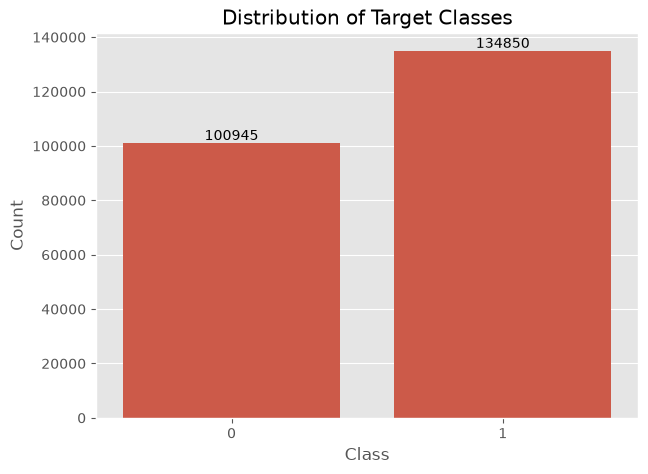

In [30]:
plt.figure(figsize=(7,5))

ax = sns.countplot(data=df, x=TARGET)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Target Classes")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()


# co-relation Matrix

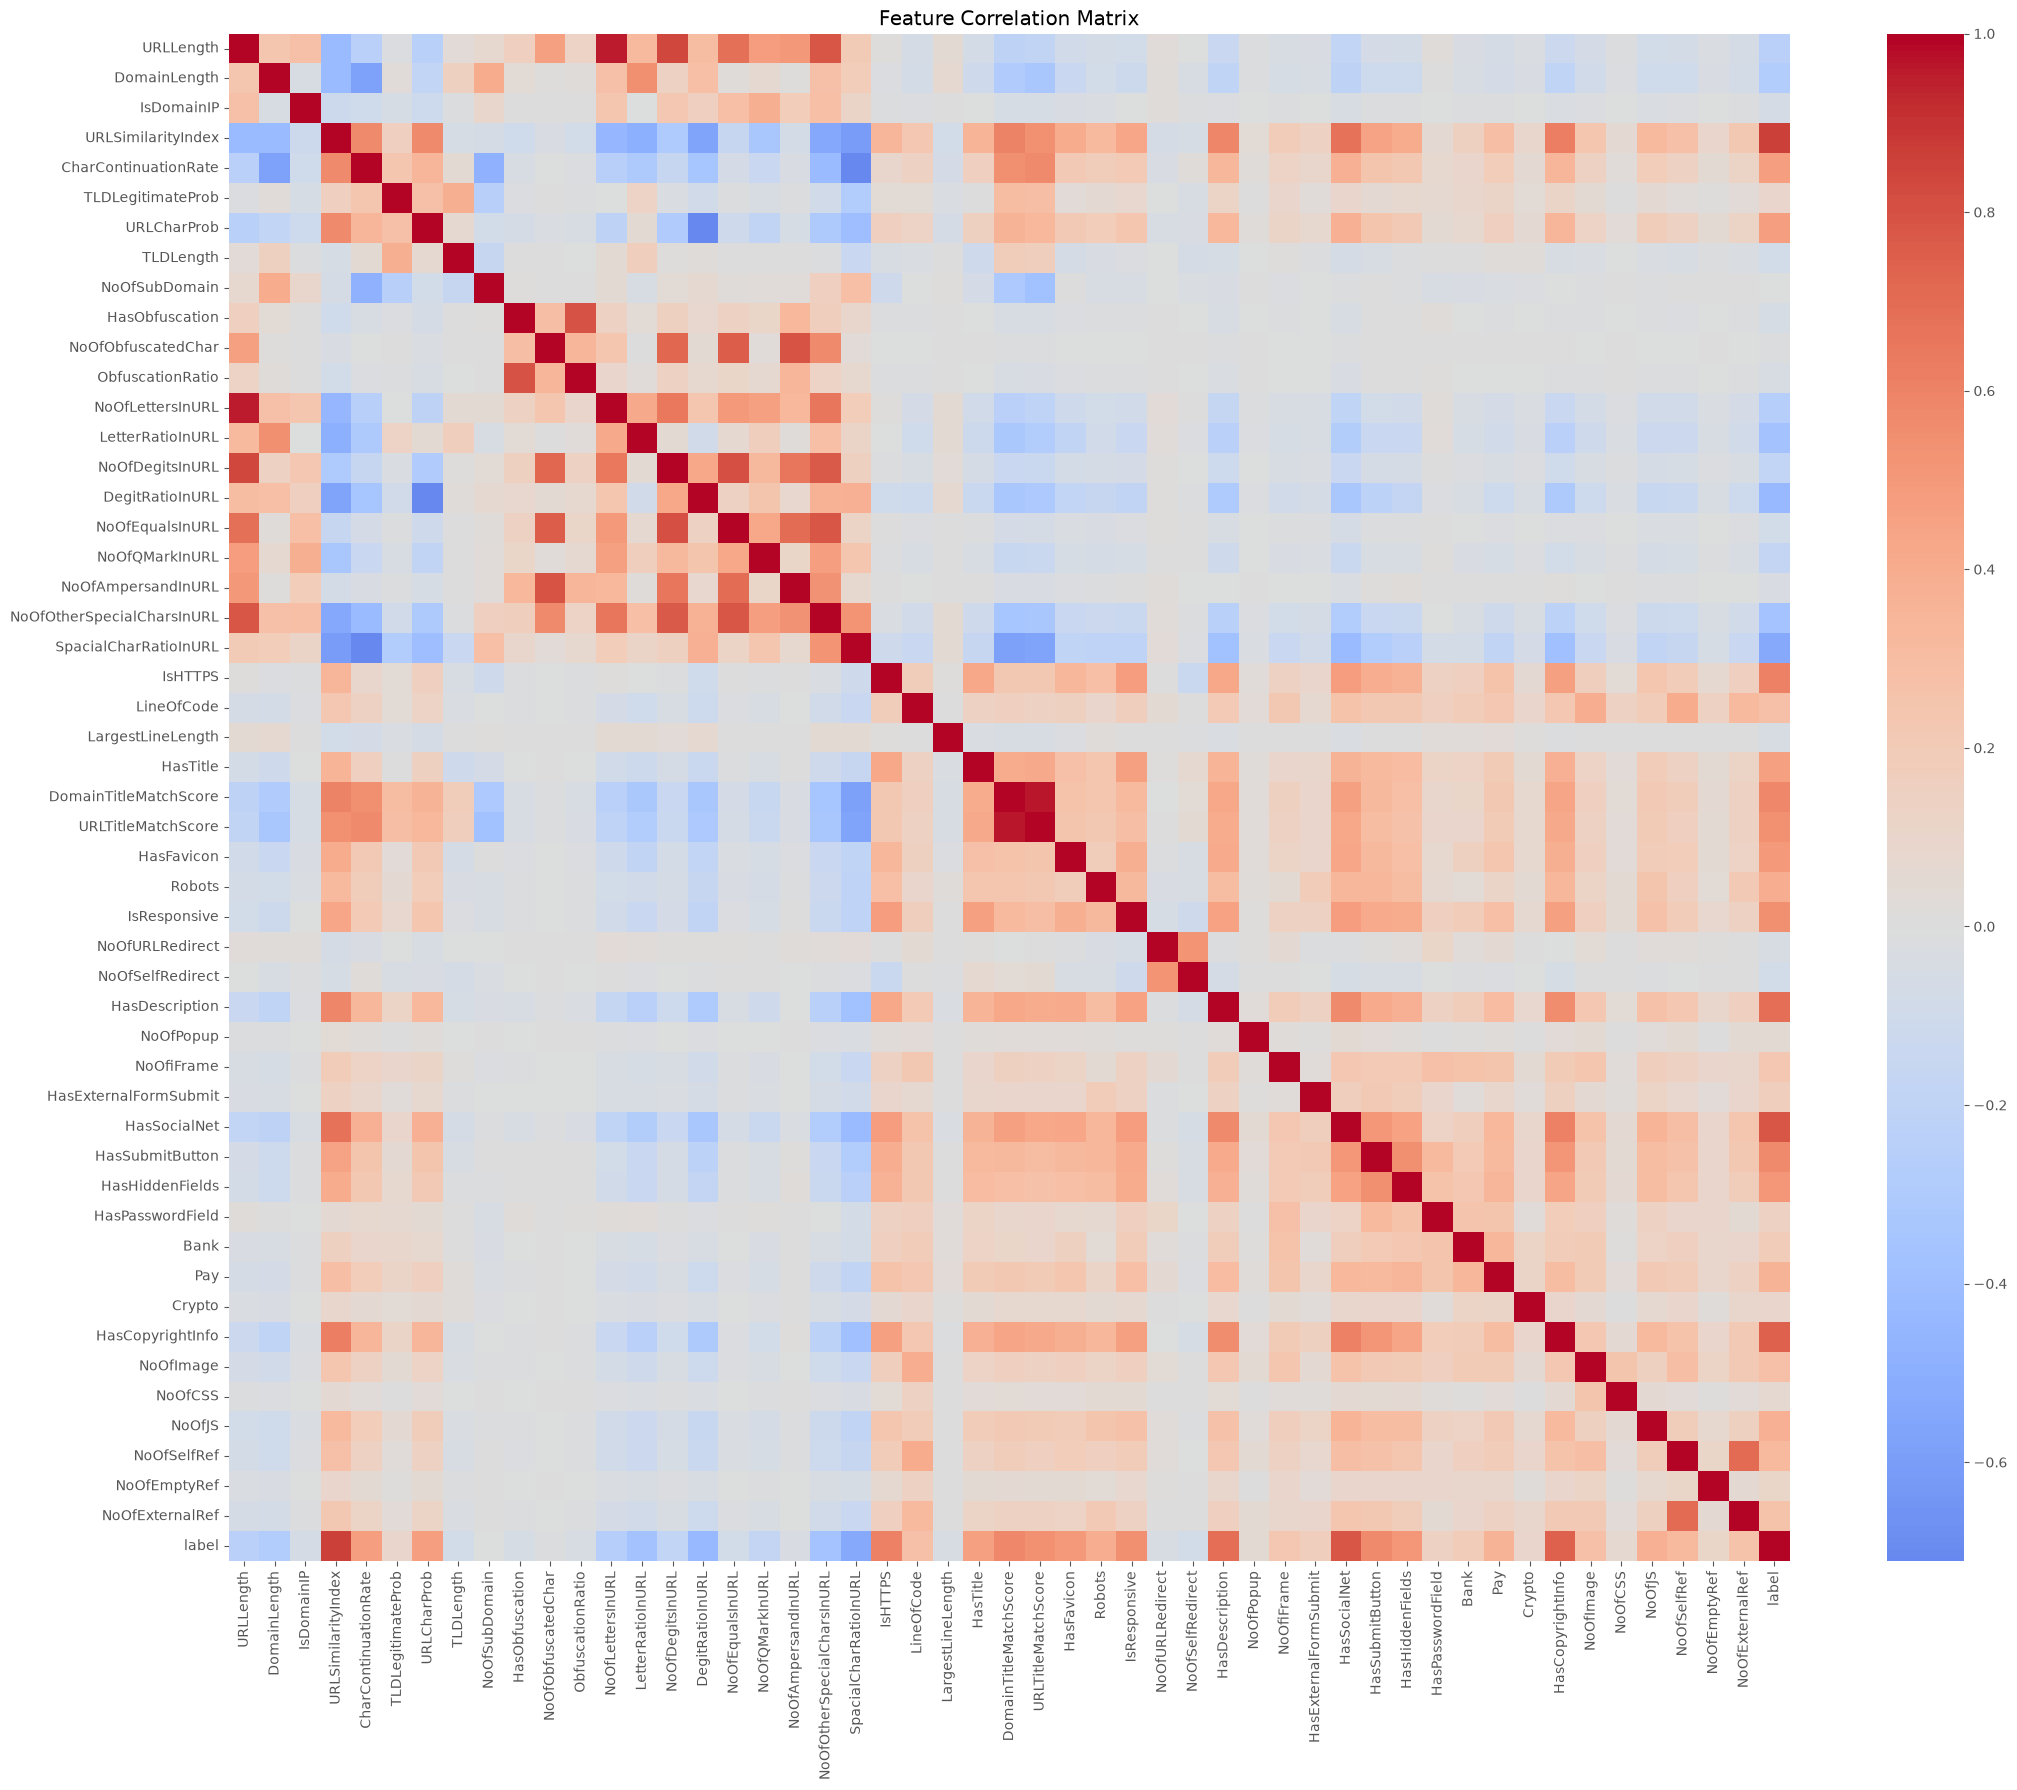

In [36]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(22,18))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=False,
    cbar=True
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()

## Class Balance

In [31]:
df[TARGET].value_counts(normalize=True)*100
class_distribution = (
    df[TARGET]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

class_distribution

label
1    57.19
0    42.81
Name: proportion, dtype: float64

## Feature Distribution

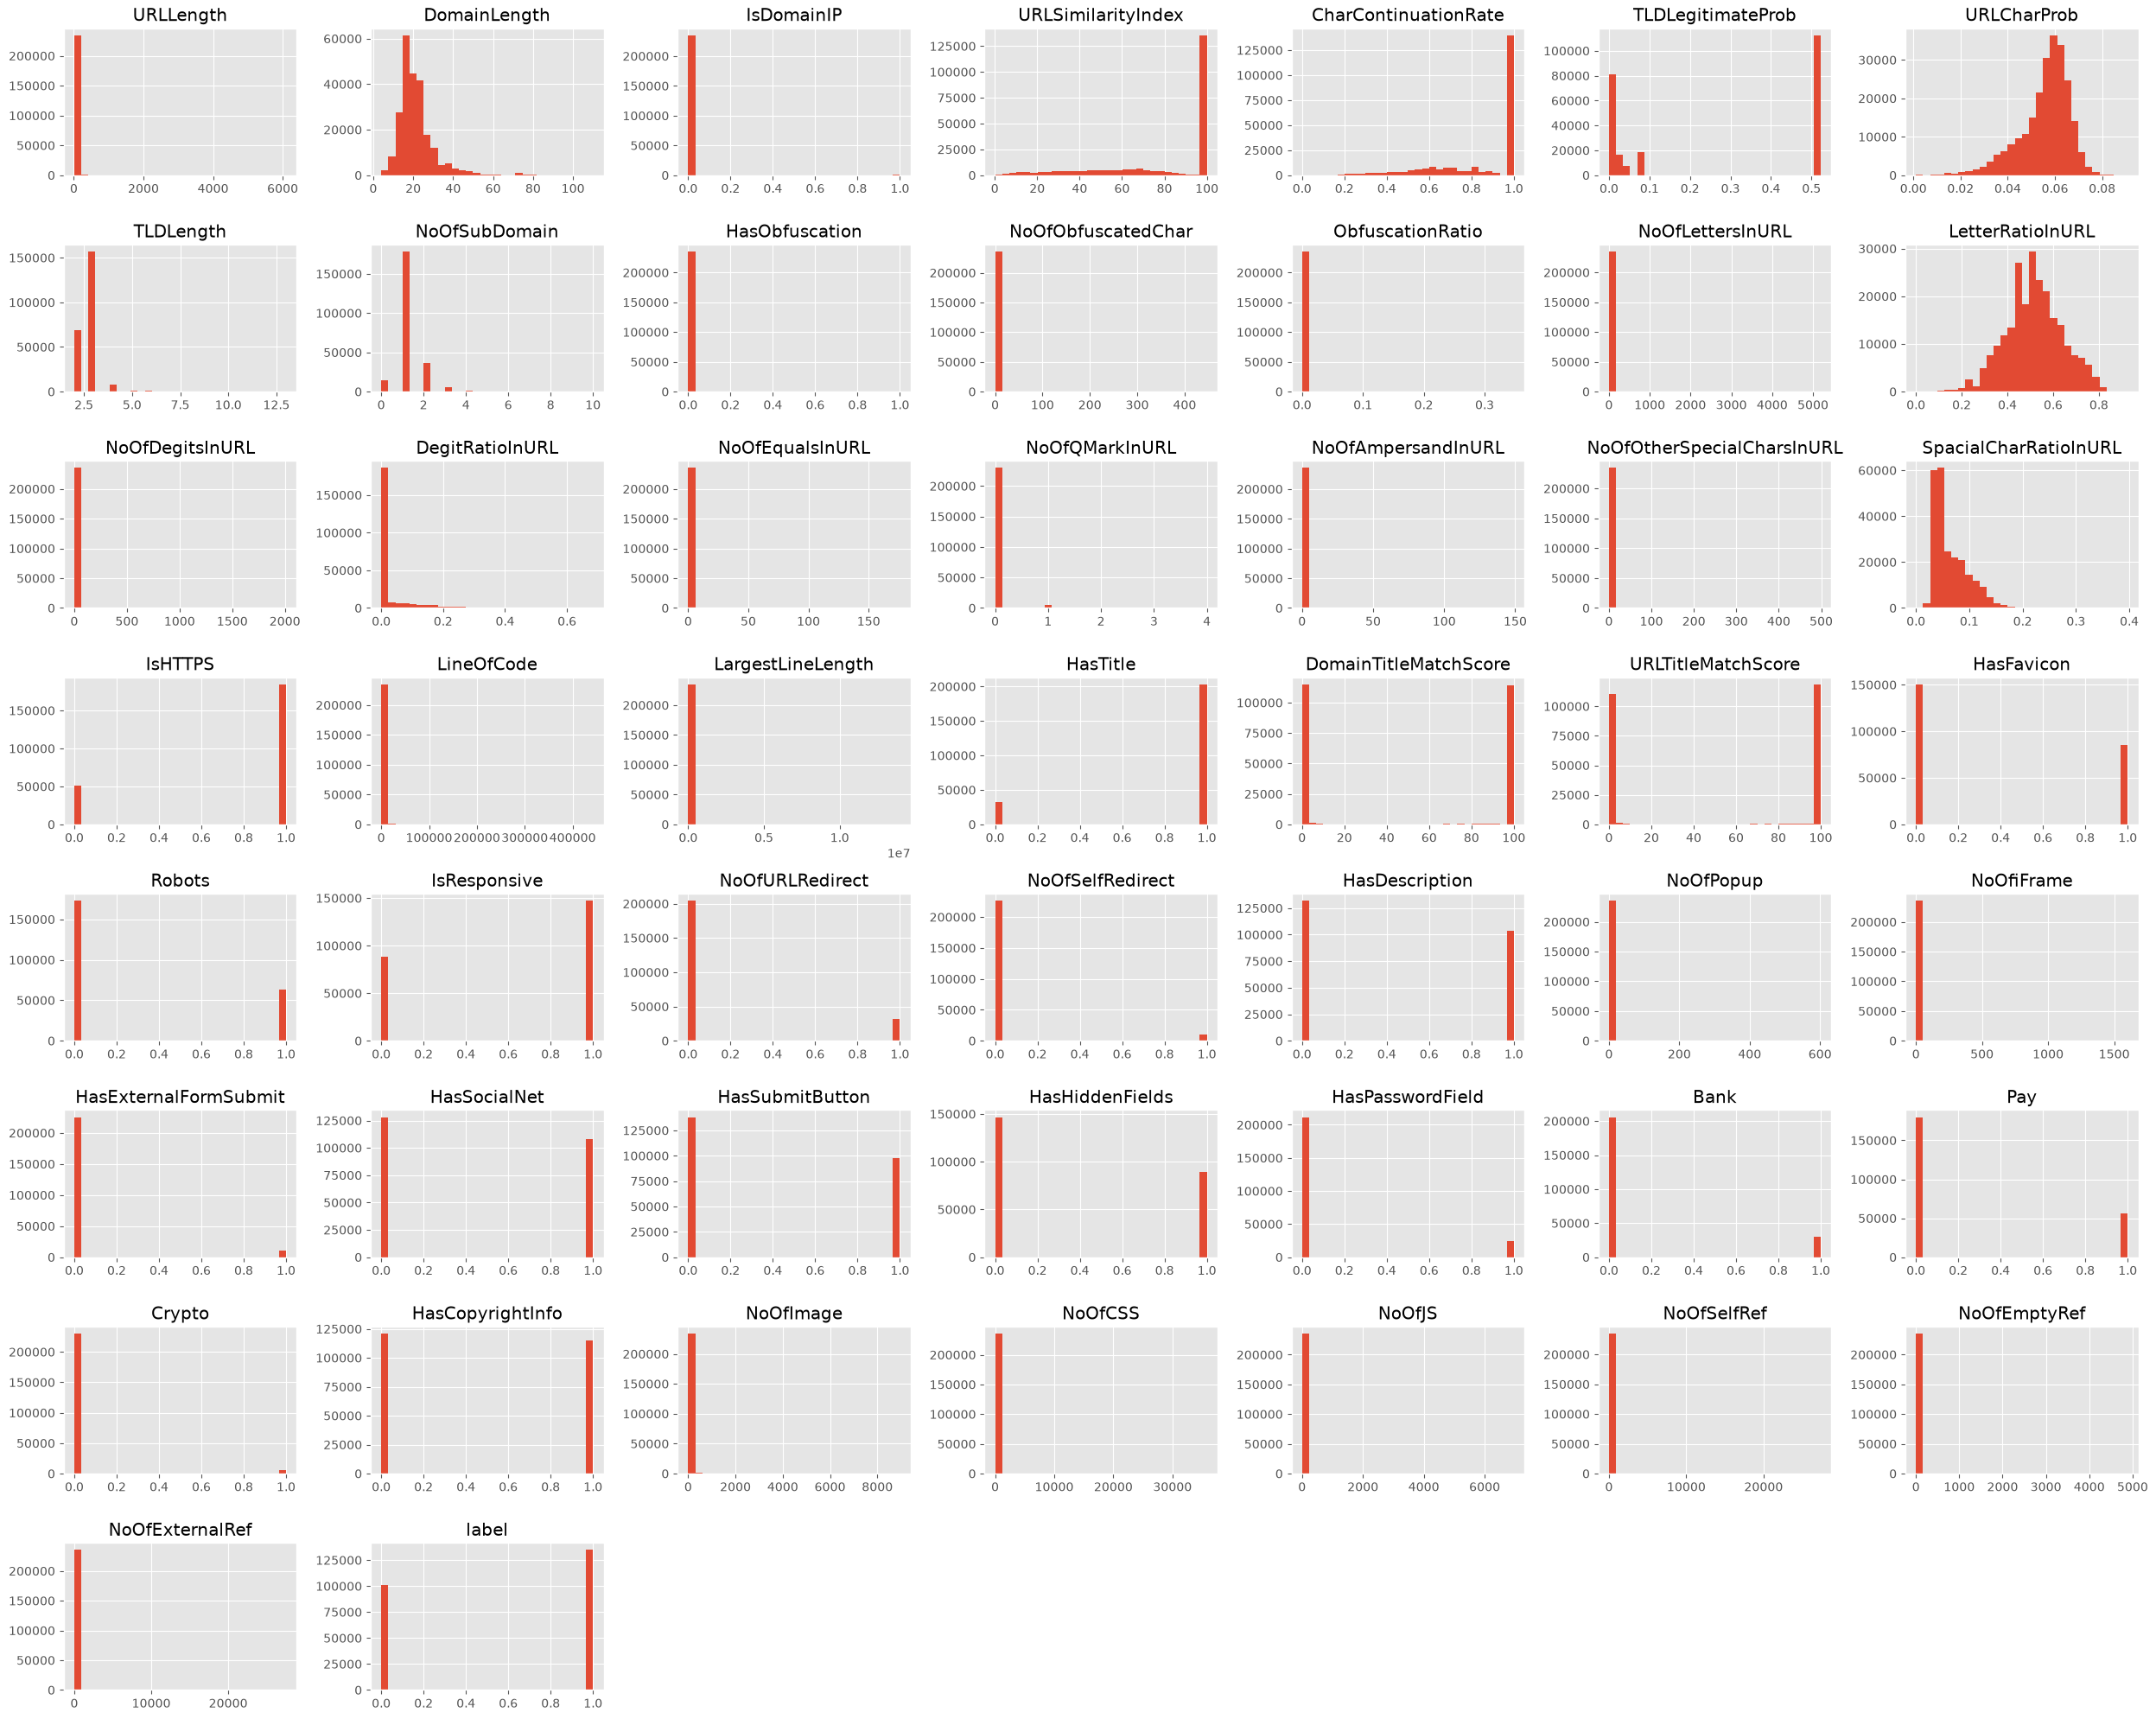

In [32]:
df.hist(
    figsize=(25,20),
    bins=30
)

plt.tight_layout()

## Outlier detection


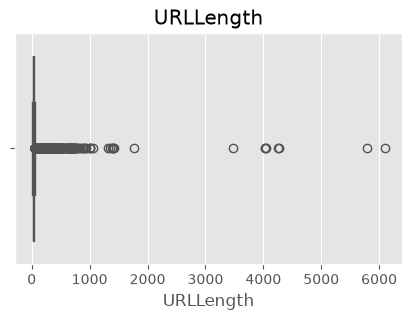

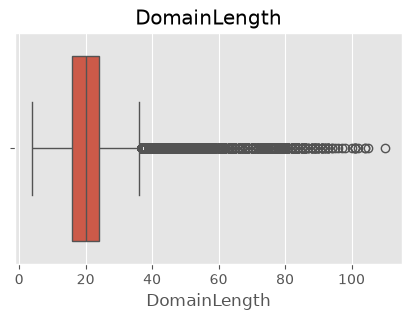

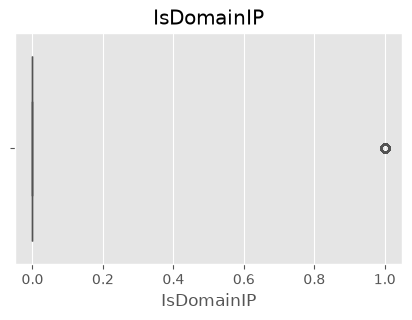

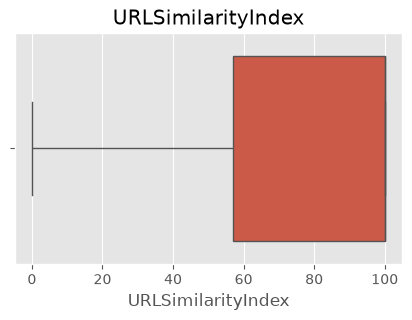

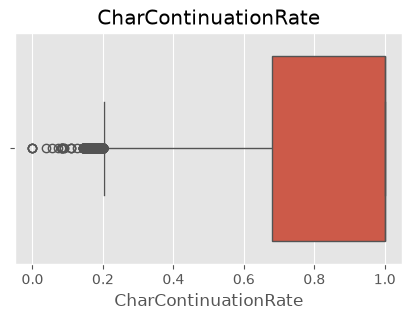

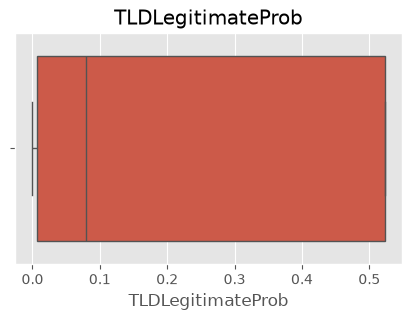

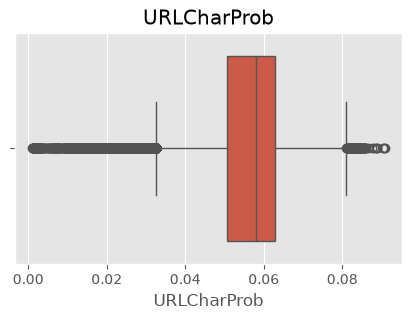

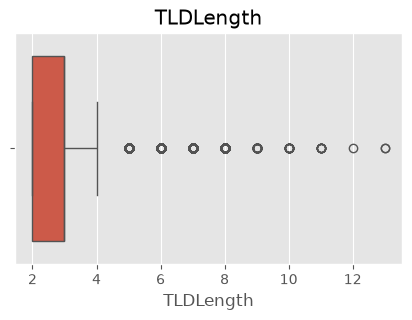

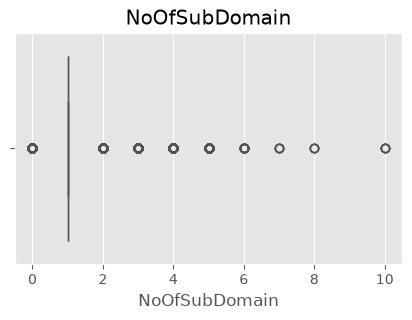

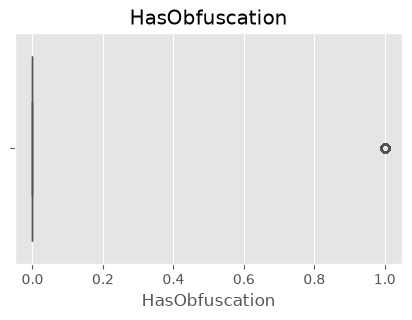

In [34]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols[:10]:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [38]:
df.to_csv("../data/processed/clean_dataset.csv", index=False)

# Summary

### Key Findings

- The dataset contains no missing values.
- No duplicate records were identified.
- Numerical and categorical features were identified.
- The target variable distribution was examined.
- Correlation analysis was performed.
- Feature distributions and outliers were inspected.

### Next Steps

- Feature Engineering
- Feature Selection
- Train-Test Split
- Baseline Logistic Regression
- Random Forest
- XGBoost
- Soft Voting Ensemble